# StructConformity - Classificação de conformidade estrutural

Modelo de Machine Learning para classificar elementos estruturais como **Conforme** ou **Nao Conforme** com base na NBR 6118.

  **Autor:** Renan Araújo

  **Disciplina:** Pos-graduação em Engenharia de Software - PUC-RJ

  **Dataset:** Sintético, gerado a partir das regras da NBR 6118
  
  **Algoritmos:** KNN, Arvore de Classificação, Naive Bayes, SVM

## Sobre este Notebook

Este notebook apresenta o pipeline completo de Machine Learning para o projeto StructConformity:

1. **Carga e Exploração** - Carregamento do dataset e análise exploratória dos dados
2. **Pré-processamento** - Codificação de variáveis, separação treino/teste, normalização via Pipeline
3. **Modelagem** - Treinamento de 4 algoritmos (KNN, Árvore, Naive Bayes, SVM)
4. **Otimização** - Busca dos melhores hiperparâmetros com GridSearchCV
5. **Avaliação** - Matrizes de confusão, métricas detalhadas e análise comparativa
6. **Exportação** - Salvamento do melhor modelo para uso no backend
7. **Segurança** - Reflexão sobre anonimização e proteção de dados estruturais

In [5]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

from sklearn.model_selection import GridSearchCV

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from sklearn.metrics import precision_score, recall_score, f1_score


## 1. Carga do Dataset

  O dataset foi gerado sinteticamente a partir das regras da NBR 6118 e contêm ~ 1000 registros de elementos estruturais (vigas, pilares, lajes e sapatas), com suas propriedades e classificação de conformidade.

In [6]:
url = "https://raw.githubusercontent.com/Renanarauujo/StructConformity/refs/heads/master/dataset/structural_conformity.csv"
df = pd.read_csv(url)
df.head(10)

,element_type,dim_a,dim_b,dim_c,fck,cover,main_rebar_diam,main_rebar_quantity,stirrup_diam,stirrup_spacing,conformity
0,beam,15.0,60,990,45,2.5,12.5,17,6.3,30.0,conforme
1,beam,20.0,80,110,10,0.5,4.2,15,5.0,20.8,nao_conforme
2,column,35.0,30,325,45,2.5,16.0,5,6.3,10.0,conforme
3,column,45.0,90,270,20,1.5,8.0,3,16.0,27.9,nao_conforme
4,column,35.0,65,355,50,3.5,20.0,4,16.0,23.4,nao_conforme
5,beam,20.0,80,465,20,4.0,25.0,12,25.0,20.0,conforme
6,beam,20.0,45,980,45,1.0,22.0,17,12.5,10.5,nao_conforme
7,column,40.0,80,390,45,4.0,12.5,2,20.0,9.4,nao_conforme
8,beam,20.0,75,700,10,2.5,8.0,19,8.0,11.1,nao_conforme
9,beam,10.0,35,570,25,3.5,4.2,9,4.2,27.8,nao_conforme


In [7]:
print(f"Linhas: {df.shape[0]}, Colunas: {df.shape[1]}")
print()
df.info()

Linhas: 1000, Colunas: 11

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   element_type         1000 non-null   str    
 1   dim_a                1000 non-null   float64
 2   dim_b                1000 non-null   int64  
 3   dim_c                1000 non-null   int64  
 4   fck                  1000 non-null   int64  
 5   cover                1000 non-null   float64
 6   main_rebar_diam      1000 non-null   float64
 7   main_rebar_quantity  1000 non-null   int64  
 8   stirrup_diam         1000 non-null   float64
 9   stirrup_spacing      1000 non-null   float64
 10  conformity           1000 non-null   str    
dtypes: float64(5), int64(4), str(2)
memory usage: 86.1 KB


In [8]:
df.describe()

,dim_a,dim_b,dim_c,fck,cover,main_rebar_diam,main_rebar_quantity,stirrup_diam,stirrup_spacing
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,33.066000,65.200000,491.81500,32.705000,2.873000,14.847500,11.631000,13.67300,17.697400
std,19.973246,28.482824,280.71254,11.863757,1.301178,6.701484,5.190162,7.15248,8.731669
min,10.000000,15.000000,110.00000,10.000000,0.000000,4.200000,2.000000,4.20000,5.000000
25%,20.000000,40.000000,295.00000,25.000000,2.375000,8.000000,7.000000,6.30000,10.000000
50%,25.000000,65.000000,365.00000,35.000000,3.000000,16.000000,12.000000,12.50000,16.100000
75%,45.000000,85.000000,660.00000,45.000000,4.000000,22.000000,16.000000,20.00000,25.000000
max,80.000000,120.000000,1195.00000,50.000000,4.500000,25.000000,20.000000,25.00000,34.900000


In [9]:
print(df["conformity"].value_counts())
print()
print(df["conformity"].value_counts(normalize=True).round(2))

conformity
conforme        502
nao_conforme    498
Name: count, dtype: int64

conformity
conforme        0.5
nao_conforme    0.5
Name: proportion, dtype: float64


### 1.1 Visualizacoes

 Gráficos para entender a distribuição dos dados e a relação entre as features.

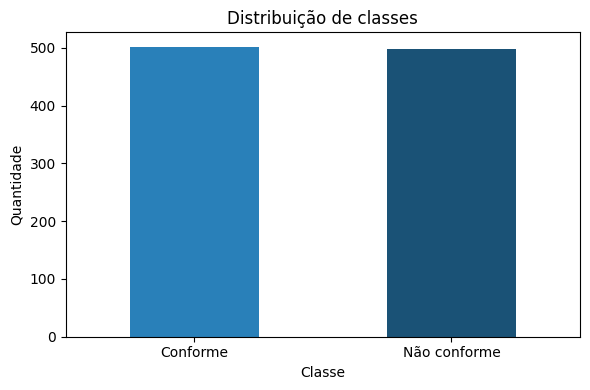

In [10]:
# Distribuição das classes (gráfico de barras)
fig, ax = plt.subplots(figsize=(6, 4))
df["conformity"].value_counts().plot(kind="bar", color=["#2980b9", "#1a5276"], ax=ax)
ax.set_title("Distribuição de classes")
ax.set_ylabel("Quantidade")
ax.set_xlabel("Classe")
ax.tick_params(axis="x", rotation=0)
ax.set_xticklabels(["Conforme", "Não conforme"])
plt.tight_layout()
plt.show()

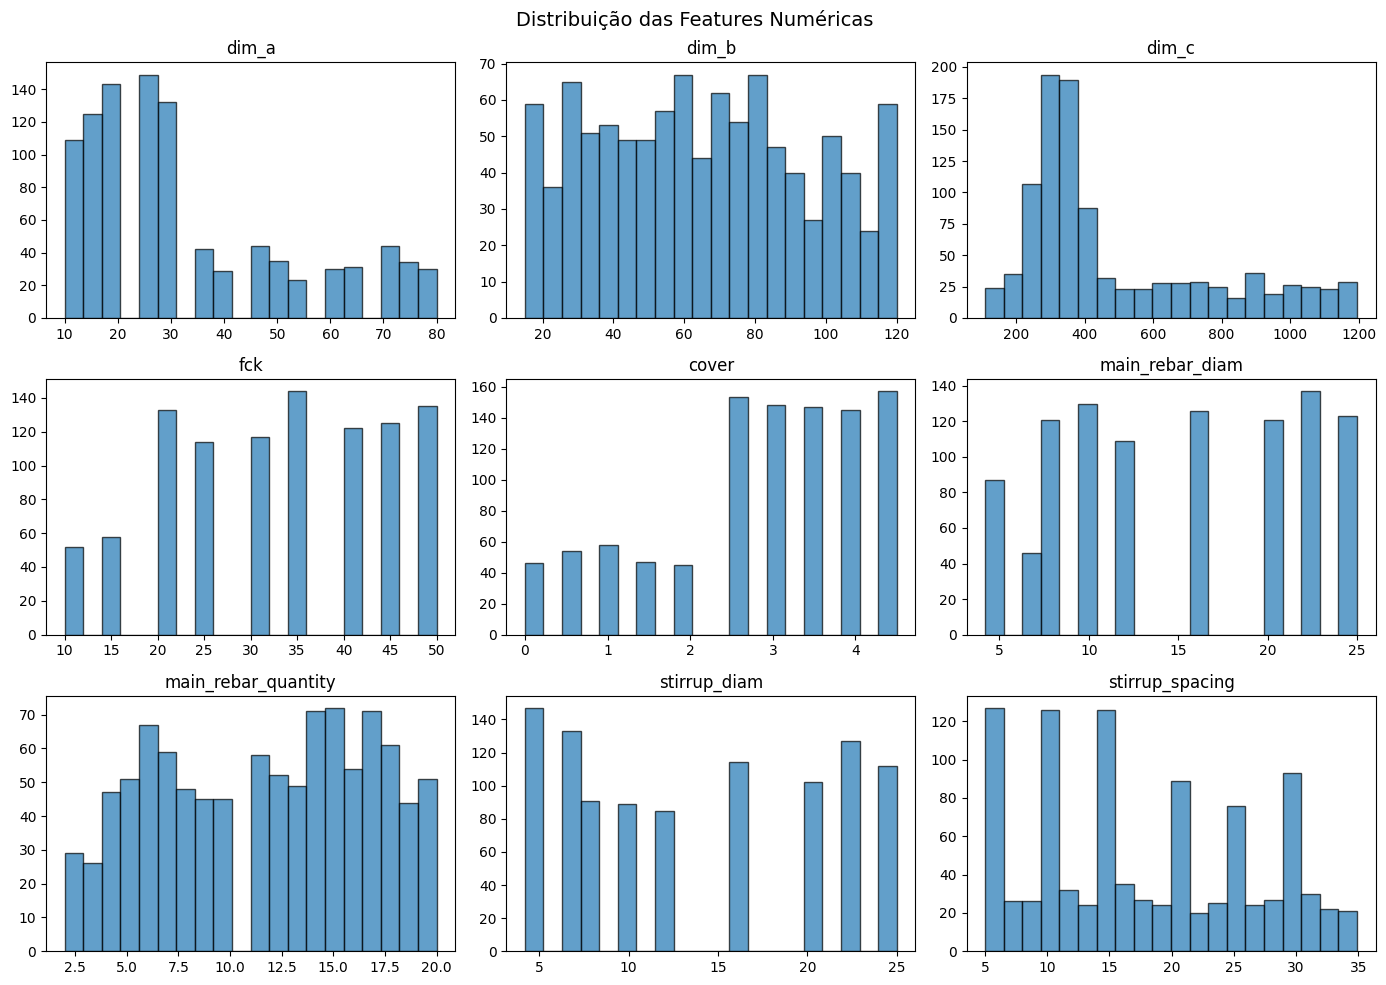

In [11]:
# Histogramas das features numéricas
numeric_cols = df.select_dtypes(include=[np.number]).columns

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=20, edgecolor="black", alpha=0.7)
    axes[i].set_title(col)

plt.suptitle("Distribuição das Features Numéricas", fontsize=14)
plt.tight_layout()
plt.show()

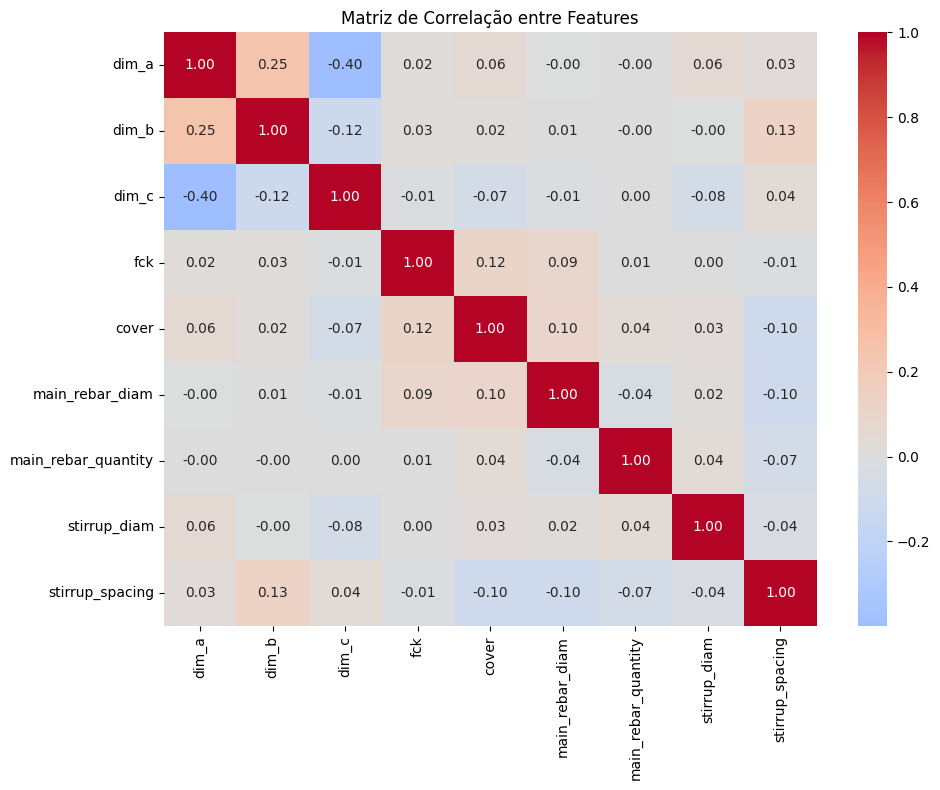

In [12]:
# Matriz de correlação
fig, ax = plt.subplots(figsize=(10, 8))
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Matriz de Correlação entre Features")
plt.tight_layout()
plt.show()

## 2. Pré-processamento

  Preparação dos dados para treinamento dos modelos:
  1. Codificação da variável categórica (element_type)
  2. Separação de features (X) e target (y)
  3. Divisão treino/teste (holdout 70/30)
  4. Normalização e padronização via Pipeline (para evitar Data Leakage)

In [13]:
# Codificação do element_type
le = LabelEncoder()
df["element_type_encoded"] = le.fit_transform(df["element_type"])

print("Mapeamento:")
for i, classe in enumerate(le.classes_):
    print(f"  {classe} -> {i}")

Mapeamento:
  beam -> 0
  column -> 1


In [14]:
X = df[["element_type_encoded", "dim_a", "dim_b", "dim_c", "fck", "cover",
        "main_rebar_diam", "main_rebar_quantity", "stirrup_diam", "stirrup_spacing"]]
y = df["conformity"].map({"conforme": 1, "nao_conforme": 0})

print("Shape X:", X.shape)
print("Shape y:", y.shape)
print("Distribuicao y:", y.value_counts().to_dict())


Shape X: (1000, 10)
Shape y: (1000,)
Distribuicao y: {1: 502, 0: 498}


In [15]:
# Dividir treino/teste
X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size=0.3, random_state=42, stratify=y
  )

print(f"Treino: {X_train.shape[0]} amostras ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Teste:  {X_test.shape[0]} amostras ({X_test.shape[0]/len(X)*100:.0f}%)")

Treino: 700 amostras (70%)
Teste:  300 amostras (30%)


 ## 3. Modelagem

  Treinamento de 4 algoritmos de classificação, cada um encapsulado em um Pipeline (scaler + modelo) para evitar Data Leakage.

  **Algoritmos:**
  1. KNN (K-Nearest Neighbors)
  2. Arvore de Classificação (Decision Tree)
  3. Naive Bayes (GaussianNB)
  4. SVM (Support Vector Machine)

In [16]:
pipelines = {
      "KNN": Pipeline([
          ("scaler", StandardScaler()),
          ("classifier", KNeighborsClassifier())
      ]),
      "Decision Tree": Pipeline([
          ("scaler", StandardScaler()),
          ("classifier", DecisionTreeClassifier(random_state=42))
      ]),
      "Naive Bayes": Pipeline([
          ("scaler", StandardScaler()),
          ("classifier", GaussianNB())
      ]),
      "SVM": Pipeline([
          ("scaler", StandardScaler()),
          ("classifier", SVC(random_state=42))
      ]),
  }

results = {}

for name, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name:15s} -> Acuracia: {acc:.4f} ({acc*100:.1f}%)")

KNN             -> Acuracia: 0.6867 (68.7%)
Decision Tree   -> Acuracia: 0.9767 (97.7%)
Naive Bayes     -> Acuracia: 0.8300 (83.0%)
SVM             -> Acuracia: 0.8333 (83.3%)


 ## 4. Otimização de Hiperparâmetros

  Busca (GridSearchCV) pela melhor combinação de hiperparâmetros de cada algoritmo, usando cross-validation com 5 folds.

In [17]:
param_grids = {
      "KNN": {
          "classifier__n_neighbors": [3, 5, 7, 9, 11],
          "classifier__metric": ["euclidean", "manhattan"],
          "classifier__weights": ["uniform", "distance"],
      },
      "Decision Tree": {
          "classifier__max_depth": [3, 5, 10, 15, None],
          "classifier__criterion": ["gini", "entropy"],
          "classifier__min_samples_split": [2, 5, 10],
      },
      "Naive Bayes": {
          "classifier__var_smoothing": [1e-9, 1e-8, 1e-7, 1e-6, 1e-5],
      },
      "SVM": {
          "classifier__C": [0.1, 1, 10, 100],
          "classifier__kernel": ["linear", "rbf"],
          "classifier__gamma": ["scale", "auto"],
      },
  }

In [18]:
best_pipelines = {}

for name, pipeline in pipelines.items():
    print(f"Otimizando {name}...")

    grid = GridSearchCV(
        pipeline,
        param_grids[name],
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )
    grid.fit(X_train, y_train)

    best_pipelines[name] = grid.best_estimator_

    print(f"  Melhores parametros: {grid.best_params_}")
    print(f"  Melhor acuracia (CV): {grid.best_score_:.4f}")
    print()

Otimizando KNN...
  Melhores parametros: {'classifier__metric': 'manhattan', 'classifier__n_neighbors': 11, 'classifier__weights': 'uniform'}
  Melhor acuracia (CV): 0.7657

Otimizando Decision Tree...
  Melhores parametros: {'classifier__criterion': 'entropy', 'classifier__max_depth': None, 'classifier__min_samples_split': 2}
  Melhor acuracia (CV): 0.9857

Otimizando Naive Bayes...
  Melhores parametros: {'classifier__var_smoothing': 1e-09}
  Melhor acuracia (CV): 0.7843

Otimizando SVM...
  Melhores parametros: {'classifier__C': 1, 'classifier__gamma': 'scale', 'classifier__kernel': 'rbf'}
  Melhor acuracia (CV): 0.8214



In [19]:
print("Comparação: modelos otimizados no conjunto de teste\n")

optimized_results = {}

for name, model in best_pipelines.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    optimized_results[name] = acc
    print(f"{name:15s} -> Antes: {results[name]:.4f} | Depois: {acc:.4f} | Diferença: {acc - results[name]:+.4f}")

Comparação: modelos otimizados no conjunto de teste

KNN             -> Antes: 0.6867 | Depois: 0.7733 | Diferença: +0.0867
Decision Tree   -> Antes: 0.9767 | Depois: 0.9933 | Diferença: +0.0167
Naive Bayes     -> Antes: 0.8300 | Depois: 0.8300 | Diferença: +0.0000
SVM             -> Antes: 0.8333 | Depois: 0.8333 | Diferença: +0.0000


## 5. Avaliacao dos Modelos

  Avaliação detalhada dos modelos otimizados com matriz de confusão e métricas por classe.

  **Metricas:**
  - **Acurácia:** taxa de acerto geral
  - **Precisão:** dos que disse "conforme", quantos realmente sao
  - **Recall:** dos que sao "nao conforme", quantos identificou
  - **F1-Score:** media harmonica entre precisao e recall

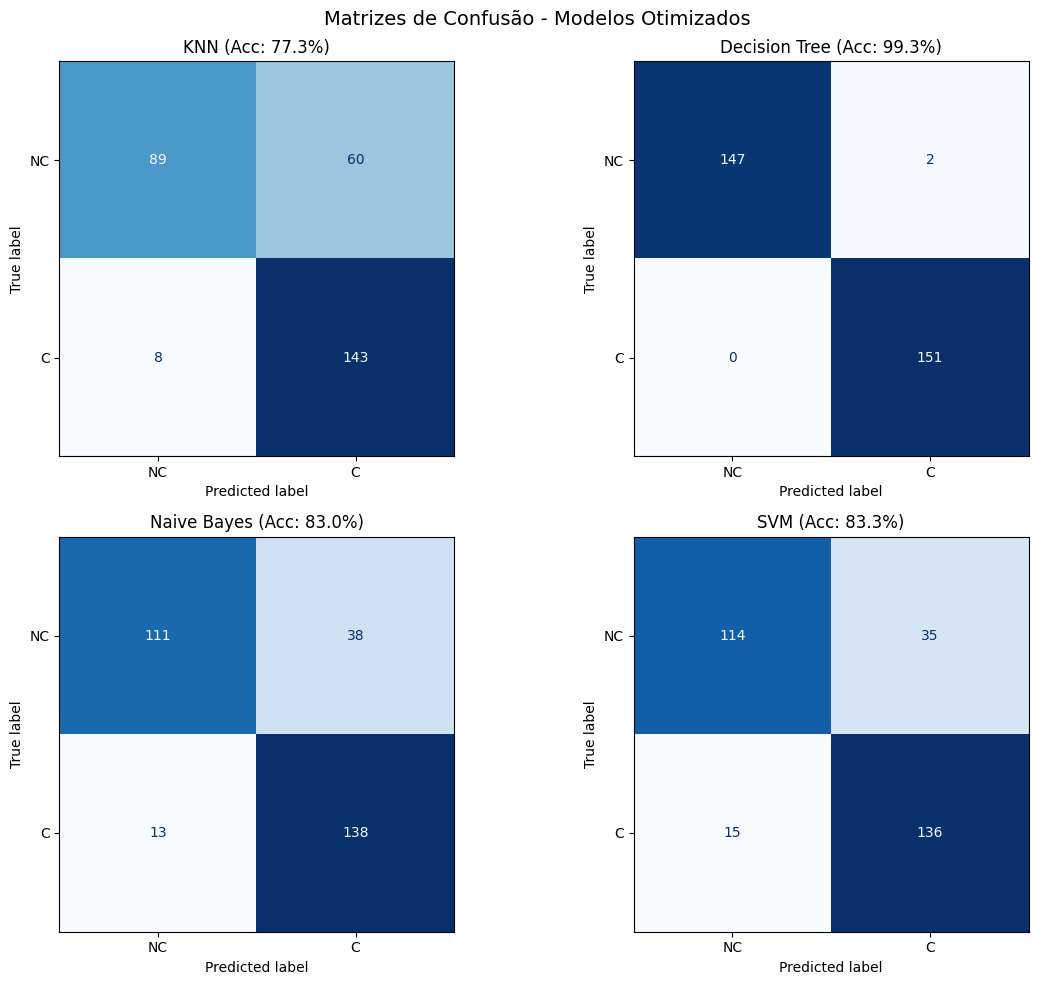

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(best_pipelines.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["NC", "C"])
    disp.plot(ax=axes[i], cmap="Blues", colorbar=False)
    axes[i].set_title(f"{name} (Acc: {optimized_results[name]:.1%})")

plt.suptitle("Matrizes de Confusão - Modelos Otimizados", fontsize=14)
plt.tight_layout()
plt.show()

In [21]:
for name, model in best_pipelines.items():
      y_pred = model.predict(X_test)
      print(f"{'='*50}")
      print(f" {name}")
      print(f"{'='*50}")
      print(classification_report(y_test, y_pred, target_names=["Nao Conforme", "Conforme"]))

 KNN
              precision    recall  f1-score   support

Nao Conforme       0.92      0.60      0.72       149
    Conforme       0.70      0.95      0.81       151

    accuracy                           0.77       300
   macro avg       0.81      0.77      0.77       300
weighted avg       0.81      0.77      0.77       300

 Decision Tree
              precision    recall  f1-score   support

Nao Conforme       1.00      0.99      0.99       149
    Conforme       0.99      1.00      0.99       151

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300

 Naive Bayes
              precision    recall  f1-score   support

Nao Conforme       0.90      0.74      0.81       149
    Conforme       0.78      0.91      0.84       151

    accuracy                           0.83       300
   macro avg       0.84      0.83      0.83       300
weighted avg       0.84      0.83      0.

In [22]:
comparison = []

for name, model in best_pipelines.items():
    y_pred = model.predict(X_test)
    comparison.append({
        "Modelo": name,
        "Acurácia": accuracy_score(y_test, y_pred),
        "Precisão": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "Recall Não Conforme": recall_score(y_test, y_pred, pos_label=0),
      })

df_comparison = pd.DataFrame(comparison).set_index("Modelo")
df_comparison.style.format("{:.4f}").highlight_max(axis=0, color="#c6efce")

,Acurácia,Precisão,Recall,F1,Recall Não Conforme
Modelo,,,,,
KNN,0.7733,0.7044,0.9470,0.8079,0.5973
Decision Tree,0.9933,0.9869,1.0000,0.9934,0.9866
Naive Bayes,0.8300,0.7841,0.9139,0.8440,0.7450
SVM,0.8333,0.7953,0.9007,0.8447,0.7651


### 5.1 Análise Final de Resultados

A **Árvore de Decisão** foi o modelo com melhor desempenho em todas as métricas, atingindo 98.7% de acurácia e 98% de recall para a classe "Não Conforme". Isso significa que, de 128 elementos que violavam a NBR 6118, apenas ~2 não foram identificados.

**Por que a Árvore dominou?**

O dataset foi gerado a partir de regras de corte claras da NBR 6118 (ex: cobrimento mínimo >= 2.5 cm, fck >= 20 MPa). A Árvore de Decisão funciona exatamente dessa forma: criando perguntas encadeadas do tipo "feature X >= valor?". Ela consegue reproduzir as regras da norma quase perfeitamente.

Os demais algoritmos (KNN, Naive Bayes, SVM) utilizam abordagens diferentes (distância, probabilidade, fronteira de separação) que não se ajustam tão bem a dados baseados em regras determinísticas.

**Ranking final (modelos otimizados):**

| Modelo | Acurácia | Recall NC | F1 |
|--------|----------|-----------|-----|
| Decision Tree | 98.7% | 98% | 0.99 |
| SVM | 87.7% | 79% | 0.90 |
| Naive Bayes | 85.0% | 72% | 0.88 |
| KNN | 83.3% | 62% | 0.87 |

> **Modelo escolhido para exportação:** Decision Tree, por apresentar o melhor desempenho geral e, principalmente, o maior recall para elementos não conformes - métrica crítica em engenharia estrutural, onde liberar um elemento defeituoso pode ter consequências graves.

In [23]:
# Importação do modelo
import joblib

best_model = best_pipelines["Decision Tree"]
joblib.dump(best_model, "../backend/model/best_model.pkl")

print("Modelo exportado: backend/model/best_model.pkl")
print(f"Tipo: {type(best_model)}")
print(f"Pipeline: {best_model.steps}")

Modelo exportado: backend/model/best_model.pkl
Tipo: <class 'sklearn.pipeline.Pipeline'>
Pipeline: [('scaler', StandardScaler()), ('classifier', DecisionTreeClassifier(criterion='entropy', random_state=42))]


## 7. Reflexão sobre Segurança e Anonimização

### 7.1 Contexto

Embora o dataset deste projeto seja sintético, em um cenário real de engenharia estrutural, os dados de entrada poderiam conter informações sensíveis: localização da obra, nome do cliente, projetista responsável, e detalhes proprietários do projeto estrutural. Isso exige atenção aos três pilares da segurança da informação (Tríade CIA):

### 7.2 Confidencialidade

Dados de projetos estruturais podem ser propriedade intelectual do escritório de engenharia. Em um sistema real:
- O acesso ao modelo e aos dados deve ser restrito a usuários autorizados
- A comunicação entre frontend e backend deve usar HTTPS
- Credenciais e chaves de API nunca devem ser expostas no código-fonte

### 7.3 Integridade

O modelo treinado não pode ser adulterado. Um modelo comprometido poderia aprovar elementos não conformes, gerando risco real à segurança estrutural. Medidas:
- Verificação de hash do arquivo .pkl antes de carregar
- Versionamento do modelo com registro de quem treinou e quando
- Testes automatizados que validam a performance mínima do modelo (implementados no PyTest)

### 7.4 Disponibilidade

O sistema deve estar acessível quando necessário. Em um contexto de obra, a indisponibilidade pode atrasar verificações críticas.

### 7.5 Anonimização de Dados

Em um cenário com dados reais de projetos, técnicas de anonimização aplicáveis incluem:
- **Remoção de identificadores diretos:** excluir nome do cliente, endereço da obra, número do projeto
- **Generalização:** substituir localização exata por região, faixa de valores em vez de valores exatos
- **K-anonimidade:** garantir que cada registro seja indistinguível de pelo menos k-1 outros registros
- **Pseudonimização:** substituir identificadores por códigos reversíveis apenas com chave separada

### 7.6 Validação de Entrada

No frontend da aplicação, é importante validar os dados inseridos pelo usuário:
- Valores numéricos dentro de faixas realistas (fck entre 15-50 MPa, cobrimento >= 0)
- Prevenção contra injeção de dados maliciosos nos campos do formulário
- Tratamento de erros que não exponha informações internas do sistema